### [SVM 분류 실습 : Fish 데이터셋 - Bream vs Smelt]

- **목표**
    - 데이터 : fish.csv 
    - 품__종 : Bream, Smelt <- Species
    - 피__처 : Length, Weight

    - Pipeline(전처리 RobustScaler, LabelEncoder, SVC 모델) + GridSearchCV로 교차검증, 튜닝 진행
    - 산점도와 결정경계선(Decision Boundary) 시각화

- **[0]모듈 로딩**

In [1]:
## 데이터 분석 관련
import os
import numpy as np
import pandas as pd

## 시각화 관련
import matplotlib.pyplot as plt
import koreanize_matplotlib

## ML 데이터셋 및 교차검증 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

## ML 전처리 관련
from sklearn.preprocessing import RobustScaler

## ML 파이프라인 관련
from sklearn.pipeline import Pipeline

## ML 모델 관련
from sklearn.svm import SVC

## ML 성능지표 관련
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [21]:
# 모든 원소를 생략 없이 출력하도록 설정
import sys
np.set_printoptions(threshold=sys.maxsize, linewidth=510)

 - **[1] 데이터 준비**

In [22]:
## 데이터 준비
DATA_FILE = '../Data/Numbers/fish.csv'

## 데이터 로딩 => 첫번째 줄 컬럼명, 데이터 구분 쉼표(,)
##              특정 컬럼 : Lenght, Height,  특정 행 : Bream, Smelt   
fishDF = pd.read_csv(DATA_FILE, 
                     usecols=['Species', 'Weight','Length'], 
                     skiprows = range(36, 146))

In [23]:
## 데이터 기본 정보 확인
fishDF.info()
fishDF.head(2)

## 클래스 개수 및 비율
print('클래스별 데이터 개수 : ', fishDF['Species'].value_counts().to_list())
print('클래스별 데이터 비율 : ', fishDF['Species'].value_counts(normalize=True).round(1).tolist())


<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  49 non-null     str    
 1   Weight   49 non-null     float64
 2   Length   49 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.3 KB
클래스별 데이터 개수 :  [35, 14]
클래스별 데이터 비율 :  [0.7, 0.3]


In [24]:
## 컬럼별 데이터 분포
fishDF.describe(include = 'all')

## -----------------------------------------------------------
## => 해석
## - Weight, Length : 값의 차이가 큼 => 스케일링 필요
## - Species : 범주형 => str --- category 형변환 => 인코딩 처리
## -----------------------------------------------------------

,Species,Weight,Length
count,49,49.000000,49.000000
unique,2,NaN,NaN
top,Bream,NaN,NaN
freq,35,NaN,NaN
mean,NaN,444.500000,27.055102
std,NaN,328.143233,10.242804
min,NaN,6.700000,9.800000
25%,NaN,19.700000,14.300000
50%,NaN,500.000000,31.000000
75%,NaN,700.000000,34.500000


- **[2] 데이터셋 분리**

In [25]:
## 피쳐와 타겟 분리
featureDF = fishDF[fishDF.columns[1:]]
targetSR  = fishDF[fishDF.columns[0]]

print(f'[TRAIN] {featureDF.shape}, {targetSR.shape}')

[TRAIN] (49, 2), (49,)


In [26]:
## 훈련/테스트 데이터 셋 분리 => 클래스 비율유지 : stratify 매개변수 설정
X_train, X_test, y_train, y_test = train_test_split(featureDF, 
                                                    targetSR,
                                                    test_size=0.2,
                                                    shuffle = True,
                                                    random_state = 12,
                                                    stratify=targetSR)

In [27]:
print(f'[TRAIN]\n{X_train.shape}, {y_train.shape}')
print(f'클래스비율: {y_train.value_counts(normalize=True).round(1).tolist()}\n')

print(f'[TEST]\n{X_test.shape}, {y_test.shape}')
print(f'클래스비율: {y_test.value_counts(normalize=True).round(1).tolist()}\n')

[TRAIN]
(39, 2), (39,)
클래스비율: [0.7, 0.3]

[TEST]
(10, 2), (10,)
클래스비율: [0.7, 0.3]



- **[3] 파이프라인 + 교차검증 + 튜닝 준비**

In [28]:
## 파이프라인 인스턴스 생성 : 전처리기(스케일러) + 모델
## => SVC모델 : 불균형 데이터 => class_weight
pipe = Pipeline(steps=[
    ('rbScaler', RobustScaler()),
    ('svcModel', SVC(class_weight='balanced'))
])

## 분류용 교차검증 인스턴스 생성
skFold = StratifiedKFold(shuffle=True, random_state=12)

## 하이퍼파라미터 설정 : 모델변수명_ _파라미터
## => 조합으로 15개 모델 생성
params = {'svcModel__C' : [0.1, 0.5, 1.0, 5, 10],
          'svcModel__kernel' :['rbf','linear', 'poly']}


## 교차검증+튜닝 인스턴스 생성
## => 불균형 데이터셋 : 성능지표, 교차검증방식, 베스트 모델 선정 기준 - refit
tunning = GridSearchCV( pipe, 
                        cv=skFold, 
                        param_grid=params,
                        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
                        refit='f1_macro',
                        return_train_score=True)

tunning

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svcModel__C': [0.1, 0.5, ...], 'svcModel__kernel': ['rbf', 'linear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1_macro', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However compu

- **[4] 교차검증 + 튜닝 진행**

In [29]:
## 진행
tunning.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svcModel__C': [0.1, 0.5, ...], 'svcModel__kernel': ['rbf', 'linear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1_macro', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However compu

- **[5] 교차검증+튜닝 결과**

In [30]:
## => 최고 파라미터, 최고 점수, 최고 모델 추출
print(f'best_params_ : {tunning.best_params_}')
print(f'best_score_  : {tunning.best_score_}')

bestModel = tunning.best_estimator_

best_params_ : {'svcModel__C': 0.1, 'svcModel__kernel': 'rbf'}
best_score_  : 1.0


In [31]:
## => 상세 학습/검증 결과 
cvDF = pd.DataFrame(tunning.cv_results_,
                    columns = ['mean_train_accuracy','mean_test_accuracy', 'mean_train_f1_macro', 'mean_test_f1_macro', 'mean_train_f1_weighted','mean_test_f1_weighted']
)
cvDF

,mean_train_accuracy,mean_test_accuracy,mean_train_f1_macro,mean_test_f1_macro,mean_train_f1_weighted,mean_test_f1_weighted
0,1.000000,1.0,1.000000,1.0,1.000000,1.0
1,0.980645,1.0,0.977234,1.0,0.980929,1.0
2,1.000000,1.0,1.000000,1.0,1.000000,1.0
3,1.000000,1.0,1.000000,1.0,1.000000,1.0
4,1.000000,1.0,1.000000,1.0,1.000000,1.0
5,1.000000,1.0,1.000000,1.0,1.000000,1.0
6,1.000000,1.0,1.000000,1.0,1.000000,1.0
7,1.000000,1.0,1.000000,1.0,1.000000,1.0
8,1.000000,1.0,1.000000,1.0,1.000000,1.0
9,1.000000,1.0,1.000000,1.0,1.000000,1.0


- **[6] 테스트 진행**

In [32]:
## => 학습/테스트 데이터셋으로 평가 진행
## 예측값 추출
y_pre = bestModel.predict(X_test)

## 클래스 결정 계산값 : decision_function()
## > 0 -- 양성 : Smelt
## < 0 -- 음성 : Bream
decision_value = bestModel.decision_function(X_test)
print(bestModel.classes_)
print(decision_value)
print(y_test.to_list())

## 점수 계산
test_score  = bestModel.score(X_test, y_test)
train_score = bestModel.score(X_train, y_train)

print(f'훈__련 점수 : {train_score} , 테스트점수: {test_score}')

['Bream' 'Smelt']
[-0.91814682 -0.95407115  0.99961102 -0.57678552 -0.99963458  0.97970631 -0.75221019  1.00209369 -0.98998218 -0.77209242]
['Bream', 'Bream', 'Smelt', 'Bream', 'Bream', 'Smelt', 'Bream', 'Smelt', 'Bream', 'Bream']
훈__련 점수 : 1.0 , 테스트점수: 1.0


Model   
          N  P
ACT N     7  0
    P     0  3

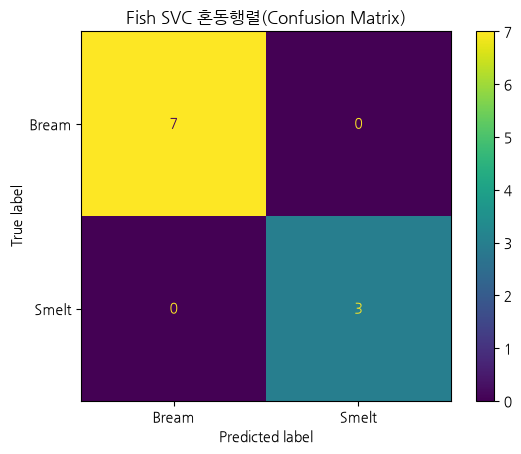

In [33]:
## => 혼동행렬 :  accuracy, precision, recall, f1-score 계산용 표
condata = confusion_matrix(y_test, y_pre)
conDF   = pd.DataFrame(condata, 
                       index=[['ACT', 'ACT'],['N','P']], 
                       columns=[['Model', 'Model'],['N','P']])
display(conDF)

## => 시각화 : ConfusionMatrixDisplay()
disp = ConfusionMatrixDisplay(  confusion_matrix=condata,
                                display_labels=bestModel.classes_ )

disp.plot()
plt.title("Fish SVC 혼동행렬(Confusion Matrix)")
plt.show()


In [34]:
## => 분류 성능 평가 보고서 보기
print( classification_report(y_test, y_pre) )

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
       Smelt       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [38]:
## -------------------------------------------------------------
## 함수이름 : plot_decision_boundary_2d
## 함수기능 : 결정경계 시각화 함수
## 매개변수 : model
##           X - DataFrame 데이터
##           y - DataFrame 정답
##           title - 제목
## 함수결과 : 없음
## -------------------------------------------------------------
def plot_decision_boundary_2d(model, X, y, title):
    ## 길이Lenght 피쳐, 무게Weight피쳐 최소, 최대값 추출
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 20, X.iloc[:, 1].max() + 20

    ## 격자 좌표 생성 
    ## 길이, 무게 크기 범위안에서 데이터 500개 생성 
    xx, yy = np.meshgrid( np.linspace(x_min, x_max, 500),
                          np.linspace(y_min, y_max, 500))

    ## 격자 데이터를 원래 피처명과 같은 DataFrame으로 생성
    grid_points = pd.DataFrame( np.c_[xx.ravel(), yy.ravel()], columns=X.columns  )

    ## 각 격자점에 대한 클래스 예측 => 양수 Smelt, 0 경계선, 음수 Bream
    Z = model.predict(grid_points)

    ## 문자 라벨을 숫자로 변환해서 contourf에 사용
    classes = np.array(model.classes_)
    Z_num = np.array([np.where(classes == label)[0][0] for label in Z])
    Z_num = Z_num.reshape(xx.shape)
    print(Z_num)

    ##=> 시각화 그래프 생성
    plt.figure(figsize=(8, 6))

    # 결정 영역
    plt.contourf(xx, yy, Z_num, alpha=0.25)
    # 결정 경계선
    #plt.contour(xx, yy, Z_num, levels=[0.5], linewidths=2)

    # 실제 데이터 산점도
    for label in classes:
        temp = X[y == label]
        plt.scatter( temp.iloc[:, 0], temp.iloc[:, 1], label=label,  edgecolor="k", alpha=0.8  )

    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(title)
    plt.legend()
    plt.show()

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

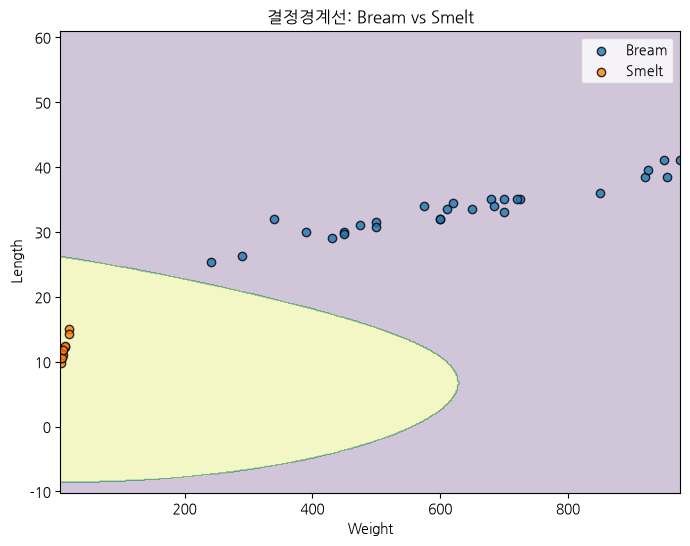

In [39]:
plot_decision_boundary_2d( bestModel, X_train, y_train, "결정경계선: Bream vs Smelt" )